# «06 — Якість даних: v1 проти v2. 

 

**Питання**: чи заплатили ми якістю за коротке вікно (4.6с проти 21.7с, 1 пакет проти 7).

**Method comparison study** («порівняння методів вимірювання»). **5 гіпотез:** викиди, кореляція динаміки, стабільність зсуву, незалежність відліків, втрати.

In [14]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

path = Path("data/stage4_pair.csv")
df = pd.read_csv(path, parse_dates=["timestamp"])

df = df[df["timestamp"] >= "2026-09-01 12:00"]

print(df.head())

print(df.groupby("node_id").size())


                     timestamp             node_id  soil_raw  soil_moisture  \
387 2026-09-01 12:01:05.646714  stage4-lowpower-v2      1237           40.0   
388 2026-09-01 12:02:42.225111     stage3-lowpower      1222           41.0   
389 2026-09-01 12:02:45.807269     stage3-lowpower      1241           39.0   
390 2026-09-01 12:02:49.389759     stage3-lowpower      1242           39.0   
391 2026-09-01 12:02:52.973601     stage3-lowpower      1239           40.0   

     soil_min  soil_max  soil_n  soil_at_ms  air_temperature  air_humidity  \
387       NaN       NaN     NaN        3050             24.3          84.6   
388       NaN       NaN     NaN          76              NaN           NaN   
389       NaN       NaN     NaN        3679              NaN           NaN   
390       NaN       NaN     NaN        7256              NaN           NaN   
391       NaN       NaN     NaN       10833              NaN           NaN   

     vbat  boot  rssi  snr  
387  3.81    49  -111  0.8 

In [2]:
v1 = df[df["node_id"] == "stage3-lowpower"]
v2 = df[df["node_id"] == "stage4-lowpower-v2"]

v1 = v1.sort_values("timestamp")
v2 = v2.sort_values("timestamp")

In [3]:
v1_gap = v1["timestamp"].diff().dt.total_seconds()
v1_new_burst = v1_gap > 45
v1["burst_id"] = v1_new_burst.cumsum()
v1["pos_in_burst"] = v1.groupby("burst_id").cumcount()
v1_burst_sizes = v1.groupby("burst_id").size()
v1_full_burst_ids = v1_burst_sizes[v1_burst_sizes == 7].index

v1 = v1[v1["burst_id"].isin(v1_full_burst_ids)]
v1 = v1[v1["pos_in_burst"] >= 1]

v1_bursts = v1.groupby("burst_id").agg(
    soil_med=("soil_raw", "median"),
    ts=("timestamp", "first"),
)

print(v1_bursts.head())
print(v1_bursts.shape)

          soil_med                         ts
burst_id                                     
0           1241.0 2026-09-01 12:02:45.807269
1           1240.5 2026-09-01 12:07:45.736800
2           1239.0 2026-09-01 12:12:45.675252
3           1237.0 2026-09-01 12:17:45.697068
4           1235.5 2026-09-01 12:22:45.531060
(374, 2)


In [4]:
d1 = v1_bursts["soil_med"].diff().abs()
d2 = v2["soil_raw"].diff().abs()

for name, d in [("v1", d1), ("v2", d2)]:
    print(name, d.median(), d.quantile(0.99), d.max())



v1 1.5 49.11999999999989 97.5
v2 2.0 36.0 48.0


In [5]:
v1_bursts.loc[d1.idxmax(), "ts"], v2.loc[d2.idxmax(), "timestamp"]

(Timestamp('2026-09-02 08:47:57.147987'),
 Timestamp('2026-09-02 08:56:15.634533'))

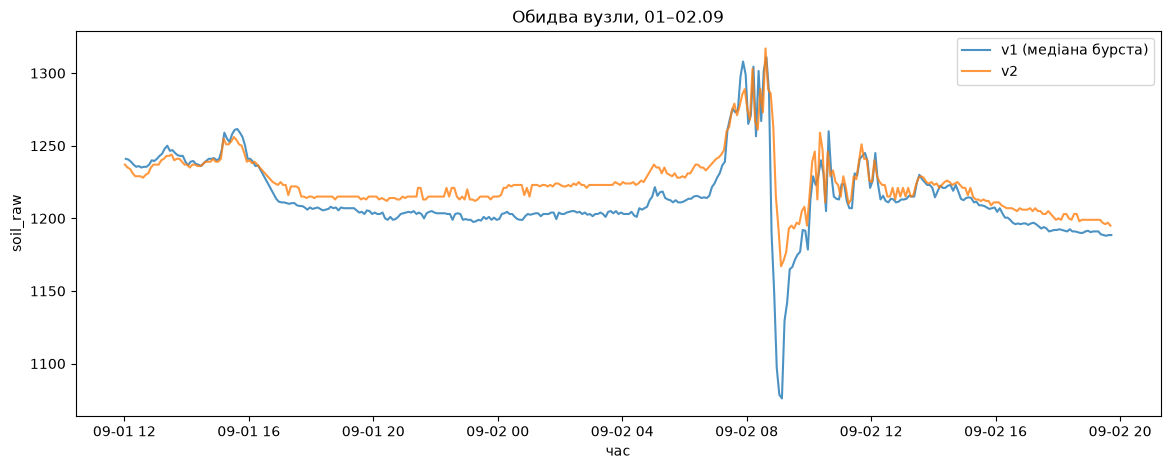

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(v1_bursts["ts"], v1_bursts["soil_med"], label="v1 (медіана бурста)", alpha=0.8)
plt.plot(v2["timestamp"], v2["soil_raw"], label="v2", alpha=0.8)
plt.xlabel("час")
plt.ylabel("soil_raw")
plt.title("Обидва вузли, 01–02.09")
plt.legend()
plt.show()

що видно на графіку: тиха ніч 01.09, дві події 02.09 (~08:47 і ~11:45), розрив між лініями гуляє.

## H1 — медіана давить викиди

In [7]:
d1 = v1_bursts["soil_med"].diff().abs()
d2 = v2["soil_raw"].diff().abs()

for name, d in [("v1 повні", d1), ("v2 повні", d2)]:
    print(name, d.median(), d.quantile(0.99), d.max())

# коли стались максимуми — перевірка, що це подія, а не викид
print(v1_bursts.loc[d1.idxmax(), "ts"], v2.loc[d2.idxmax(), "timestamp"])

v1 повні 1.5 49.11999999999989 97.5
v2 повні 2.0 36.0 48.0
2026-09-02 08:47:57.147987 2026-09-02 08:56:15.634533


In [8]:
quiet1 = v1_bursts[(v1_bursts["ts"] >= "2026-09-01 12:00") & (v1_bursts["ts"] < "2026-09-02 04:00")]
quiet2 = v2[(v2["timestamp"] >= "2026-09-01 12:00") & (v2["timestamp"] < "2026-09-02 04:00")]

d1q = quiet1["soil_med"].diff().abs()
d2q = quiet2["soil_raw"].diff().abs()

for name, d in [("v1 quiet", d1q), ("v2 quiet", d2q)]:
    print(name, d.median(), d.quantile(0.99), d.max())

v1 quiet 1.0 9.509999999999962 23.0
v2 quiet 1.0 8.279999999999973 14.0


**Вердикт H1: підтверджена, але м'яко.**

На повних даних хвости різняться вдвічі (max 97.5 проти 48) — але обидва максимуми припали на ту саму мить (08:47 02.09), тобто це реальна подія в ґрунті, а не викиди сенсора. На тихому вікні (01.09 12:00 – 02.09 04:00), де лишається чистий шум: медіани однакові (1.0 = 1.0), p90 близькі, і лише максимум у v2 коротший — 14 проти 23. Медіана в прошивці справді підрізає рідкісні викиди, але буденна якість двох схем ідентична.

## H2 — та сама фізика

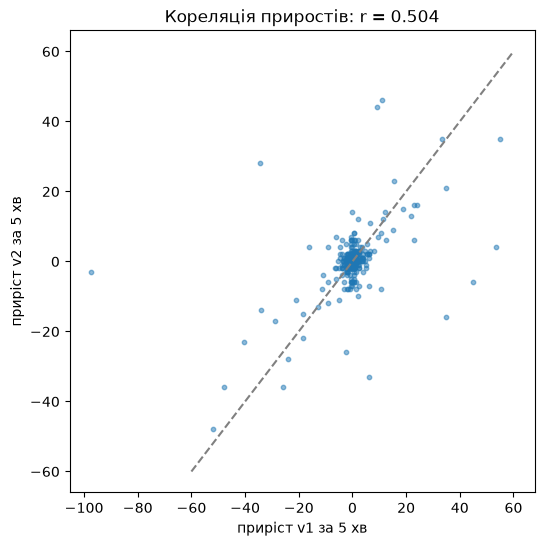

In [9]:
s1 = v1_bursts.set_index("ts")["soil_med"].resample("5min").mean()
s2 = v2.set_index("timestamp")["soil_raw"].resample("5min").mean()
r = s1.diff().corr(s2.diff())

dd1 = s1.diff()
dd2 = s2.diff()

plt.figure(figsize=(6, 6))
plt.scatter(dd1, dd2, s=10, alpha=0.5)
lim = 60
plt.plot([-lim, lim], [-lim, lim], color="gray", linestyle="--")  # діагональ y=x
plt.xlabel("приріст v1 за 5 хв")
plt.ylabel("приріст v2 за 5 хв")
plt.title(f"Кореляція приростів: r = {dd1.corr(dd2):.3f}")
plt.show()

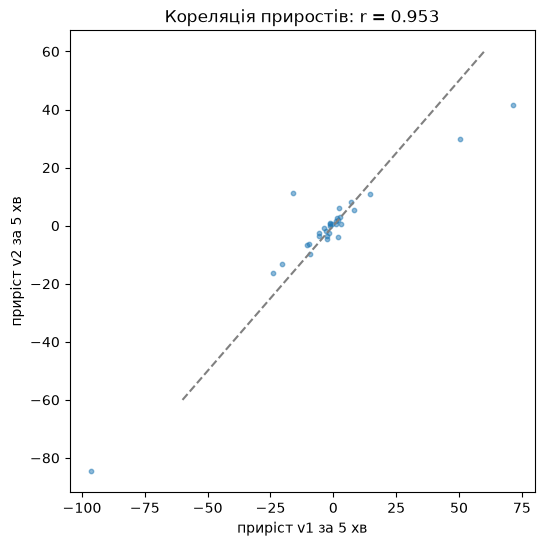

In [10]:
s1h = v1_bursts.set_index("ts")["soil_med"].resample("1h").mean()
s2h = v2.set_index("timestamp")["soil_raw"].resample("1h").mean()

rh = s1h.diff().corr(s2h.diff())

dd1h = s1h.diff()
dd2h = s2h.diff()

plt.figure(figsize=(6, 6))
plt.scatter(dd1h, dd2h, s=10, alpha=0.5)
lim = 60
plt.plot([-lim, lim], [-lim, lim], color="gray", linestyle="--")  # діагональ y=x
plt.xlabel("приріст v1 за 5 хв")
plt.ylabel("приріст v2 за 5 хв")
plt.title(f"Кореляція приростів: r = {dd1h.corr(dd2h):.3f}")
plt.show()

**Вердикт H2: підтверджена — v2 бачить ту саму фізику.**

Кореляція приростів залежить від масштабу, і всі три числа повчальні:
- тихе вікно: r = 0.385 — прирости там майже чистий шум, а шум двох приладів некорельований за визначенням;
- повні дані, сітка 5 хв: r = 0.504 — цикли вузлів не синхронні, різкий фронт події падає в різні біни (v1: −98, v2: −3 у сусідніх);
- повні дані, сітка 1 год: **r = 0.953** — розсинхрон тоне в біні, залишається спільна фізика.

Коротке вікно 4.6 с не пропустило нічого, що бачило довге 21.7 с.

## H3 - рівні непорівнянні

-5.5416666666667425 37.25 10.052990845959592


<Axes: title={'center': 'Різниця рівнів v2 − v1 (годинна сітка)'}, xlabel='timestamp'>

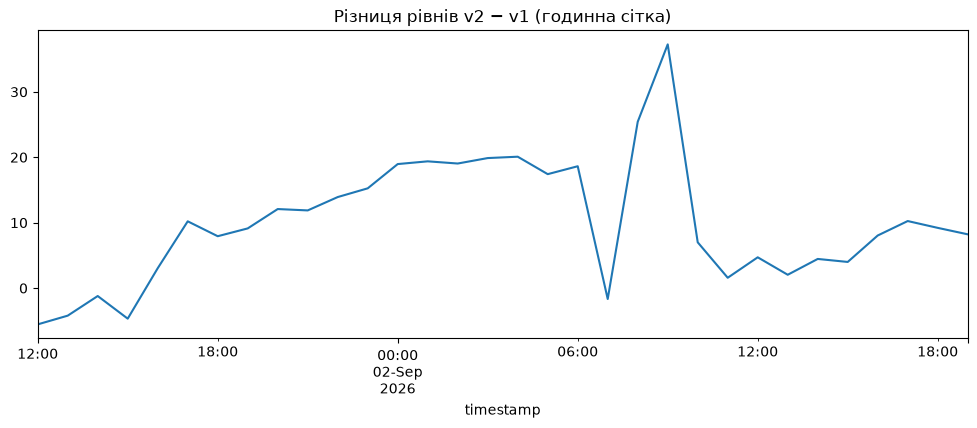

In [11]:
gap = s2h - s1h
print(gap.min(), gap.max(), gap.mean())
gap.plot(figsize=(12, 4), title="Різниця рівнів v2 − v1 (годинна сітка)")

**Вердикт H3: підтверджена — рівні порівнювати не можна.**

Розбіжність v2 − v1 гуляє від −5.5 до +37 за 42 години; середнє (+10) не описує нічого. Найпоказовіше — стрибок до +37 під час події 08:47: та сама вода дійшла до двох щупів у різних дірках зовсім по-різному (v1 впав на ~90 глибше). Це фізика ділянки, а не властивість приладів. Віднімати «калібрувальну константу» між щупами безглуздо — порівнюється лише динаміка (прирости), що H2 і робить.

## H4 - відліки 50 мс незалежні

In [12]:
rng = v2["soil_max"] - v2["soil_min"]
print(rng.describe())
print("частка нульових:", (rng == 0).mean())

count    99.000000
mean      2.535354
std       2.158576
min       0.000000
25%       1.000000
50%       2.000000
75%       3.500000
max       8.000000
dtype: float64
частка нульових: 0.03978779840848806


**Вердикт H4: підтверджена — відліки через 50 мс незалежні.**

Медіана розмаху трьох відліків = 2.0 → σ на відлік ≈ 2.0/1.69 ≈ 1.2 — той самий масштаб, що шум v1 (1.74, ноутбук 01). Нульовий розмах лише у 4% циклів (з цілочисельним АЦП стільки й очікується). Якби прошивка читала один вимір тричі, розмах був би нулем майже завжди. `SOIL_GAP_MS` = 50 мс достатній.

*Обмеження: поля soil_min/soil_max доїхали лише у 99 із 377 циклів (увімкнені посеред прогону) — висновок стоїть на чверті вибірки.*


## H5 - втрати пакетів

In [13]:
hours = (df["timestamp"].max() - df["timestamp"].min()).total_seconds() / 3600
expected = hours * 12          # циклів очікувано (12 на годину)

print(expected, len(v2), len(v1_full_burst_ids))

380.44435176666667 377 374


**Вердикт H5: підтверджена — втрати мізерні.**

За ~31.7 год очікувалось ~380 циклів. v2 має 377 (порожніх ~0.9% — один на ~8 годин), v1 — 374 повних бурсти з ~380 (~1.7% стали неповними). Страх «втрата єдиного пакета v2 = втрата всього циклу» на практиці коштує одну 15-хвилинну дірку зрідка — а ґрунт за 15 хв міняється менше за шум (ноутбук 02). Ризик прийнятний без ACK і повторів.



## Підсумок: чи заплатили ми якістю за коротке вікно

| гіпотеза | число | вердикт |
|---|---|---|
| H1: медіана давить викиди | тихе вікно: max 23 (v1) проти 14 (v2), p99 9.5 проти 8.3 | ✓ v2 трохи чистіший; драматична різниця 98/48 була реальними подіями, не викидами |
| H2: та сама фізика | r приростів = 0.953 (година); 0.504 (5хв, розсинхрон фаз); 0.385 (тихе вікно, чистий шум) | ✓ коротке вікно нічого не пропустило |
| H3: рівні непорівнянні | розбіжність гуляє −5.5…+37 за 42 год (стрибок +37 — під час події) | ✓ віднімати константу не можна; порівнюємо лише динаміку |
| H4: відліки 50 мс незалежні | медіана розмаху 2.0 → σ ≈ 1.2 (проти 1.74 у v1); нулів 4% | ✓ незалежні; але поля min/max доїхали лише в 99/377 циклів |
| H5: втрати пакетів | v2: 377/380 циклів (0.9% порожніх); v1: 374/380 повних бурстів | ✓ один порожній цикл на ~8 год — менше за шум |

**Скільки коштувала економія в одиницях якості: ≈ нуль.**
Вікно коротше в 4.7 раза, пакетів усемеро менше — а якість даних не гірша,
подекуди краща (викиди, зсув позиції 0 викинуто в прошивці).

**Обмеження:** 42 години, два дні з подіями, поля min/max — чверть вибірки.
Довші дані етапу 4 (розведення 5/15 хв, обмін щупів) уточнять, не перевернуть.